# Optimización de Hiperparámetros y Análisis Geométrico (Dry Bean Dataset)

Este proyecto aborda dos problemas fundamentales en el aprendizaje automático:
1. **Aprendizaje No Supervisado (Pseudo-etiquetado):** Evaluación de la capacidad de algoritmos como K-Means y MeanShift para deducir la topología de los datos y agruparlos lógicamente sin conocer sus etiquetas reales.
2. **Aprendizaje Supervisado (Successive Halving):** Implementación de un motor de entrenamiento concurrente para Regresión Logística y SVM (vía SGD) que optimiza el uso de recursos descartando configuraciones subóptimas cada 5 épocas.

**Dataset:** Dry Bean Dataset (UCI). Características morfológicas de 7 tipos de frijoles.

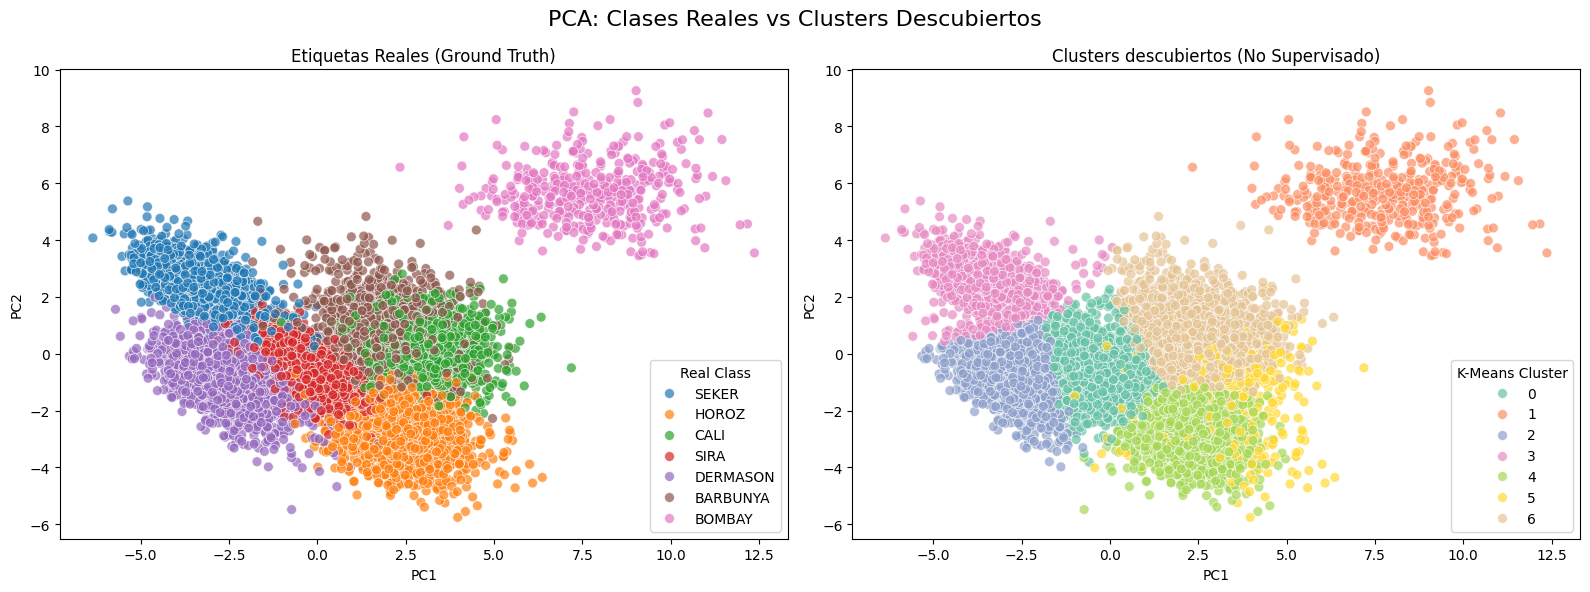

Varianza explicada por las 2 componentes principales: 81.92%


In [1]:
import sys
import os
import pandas as pd
from sklearn.cluster import KMeans

# Añadir la ruta 'src' para poder importar nuestros módulos
sys.path.append(os.path.abspath('../src'))
from utils import plot_pca_clusters

# 1. Cargar datos (Corregido el pd.read_csv)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['Class']

# 2. Entrenar el mejor K-Means de la Fase 2 (7 clusters)
kmeans_best = KMeans(n_clusters=7, init='random', n_init=10, max_iter=300, random_state=42)
clusters_pred = kmeans_best.fit_predict(X_train)

# 3. Visualizar con PCA
plot_pca_clusters(X_train, y_train, clusters_pred)

### Análisis de Resultados: Aprendizaje No Supervisado 

Al reducir la dimensionalidad del conjunto de datos de 16 características a 2 componentes principales (reteniendo un sólido **81.92% de la varianza**), podemos observar visualmente la topología del dataset:

1. **Separación natural:** Clases como `BOMBAY` se encuentran espacialmente aisladas, lo que permite que algoritmos geométricos como K-Means las agrupen con casi un 100% de precisión (Cluster 1).
2. **Solapamiento central:** Existe una gran densidad de puntos superpuestos entre las clases `SIRA`, `DERMASON`, `CALI`, y `SEKER`. 
3. **Límites de K-Means:** Dado que K-Means realiza particiones espaciales (celdas de Voronoi), "corta" arbitrariamente esta masa central de datos solapados. Esto explica teóricamente por qué el **Accuracy del pseudo-etiquetado se estanca en ~66%**. El algoritmo no cuenta con la información supervisada necesaria para trazar fronteras de decisión complejas en zonas de alta confusión morfológica.

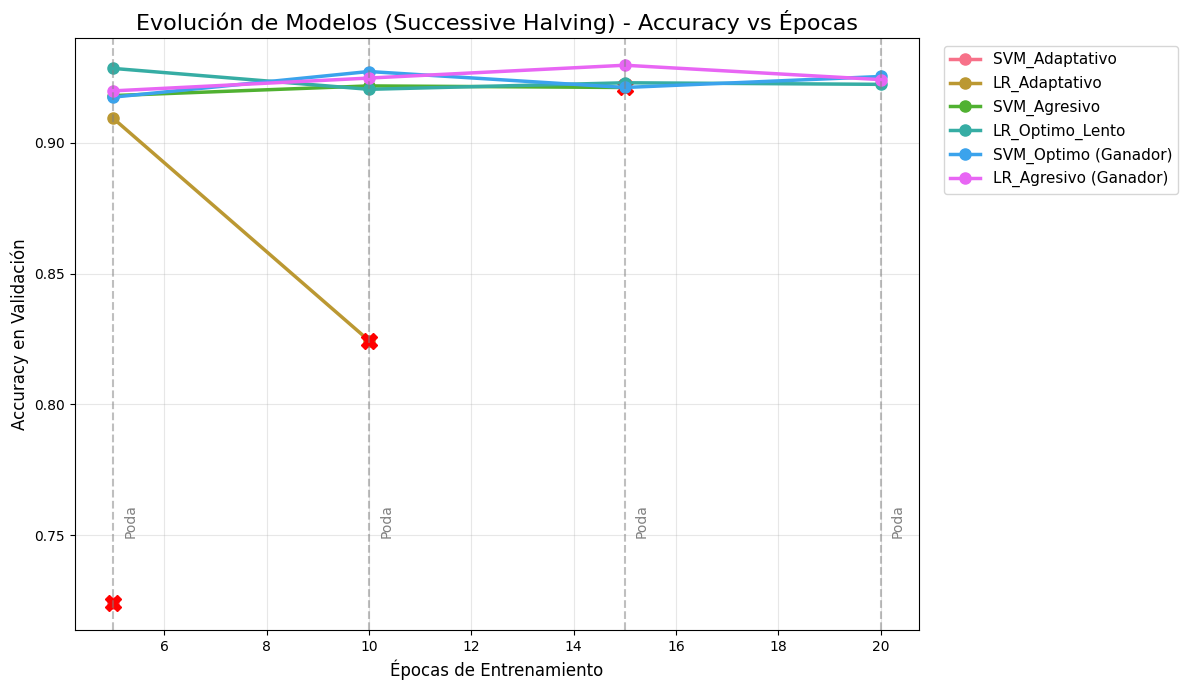

In [2]:
# Importar la nueva función
from utils import plot_successive_halving

# Reconstrucción de los resultados de consola de la Fase 3
# Anotamos las épocas en las que cada modelo sobrevivió y su accuracy respectivo
history = {
    'SVM_Adaptativo': {
        'epochs': [5],
        'acc': [0.7240] # Podado en la época 5
    },
    'LR_Adaptativo': {
        'epochs': [5, 10],
        'acc': [0.9094, 0.8244] # Colapsó y fue podado en la época 10
    },
    'SVM_Agresivo': {
        'epochs': [5, 10, 15],
        'acc': [0.9180, 0.9217, 0.9211] # Podado en la época 15
    },
    'LR_Optimo_Lento': {
        'epochs': [5, 10, 15, 20],
        'acc': [0.9284, 0.9204, 0.9229, 0.9223] # Podado en la época 20
    },
    'SVM_Optimo (Ganador)': {
        'epochs': [5, 10, 15, 20],
        'acc': [0.9174, 0.9272, 0.9211, 0.9253] # Sobreviviente
    },
    'LR_Agresivo (Ganador)': {
        'epochs': [5, 10, 15, 20],
        'acc': [0.9198, 0.9247, 0.9296, 0.9241] # Sobreviviente
    }
}

plot_successive_halving(history)

### Análisis de Resultados: Aprendizaje Supervisado y Successive Halving

Al observar las curvas de aprendizaje y el proceso de poda iterativa, podemos extraer tres conclusiones teóricas fundamentales:

1. **El poder de la Supervisión:** A diferencia del clustering (66% de precisión), los modelos lineales alcanzaron un **>90% de precisión**. Esto demuestra que, aunque las clases estén geométricamente solapadas, los algoritmos supervisados logran encontrar hiperplanos de separación en el espacio de 16 dimensiones al ponderar correctamente características sutiles, guiados por la función de pérdida (Log-Loss o Hinge).
2. **El riesgo de las Tasas Adaptativas:** Modelos como el `LR_Adaptativo` sufrieron un colapso en la época 10. La reducción drástica (escalonada) de la tasa de aprendizaje ante el estancamiento del error puede provocar que el modelo quede atrapado en mínimos locales subóptimos o se sobreajuste al ruido de los minibatches.
3. **Sinergia en los Hiperparámetros (Los Ganadores):** - La **SVM_Optimo** triunfó gracias a su decaimiento de tasa de aprendizaje teóricamente diseñado (heurística de Bottou), permitiendo una convergencia suave.
   - La **LR_Agresivo** mantuvo su competitividad usando un `batch_size` pequeño y una tasa constante, lo que inyectó ruido estocástico al gradiente, actuando como regularizador para evitar el sobreajuste.

**Conclusión del Proyecto:**
La técnica de *Successive Halving* demostró ser altamente eficiente para la optimización de hiperparámetros, eliminando modelos inestables prematuramente y ahorrando recursos computacionales, dejando únicamente a las configuraciones matemáticamente más robustas para la evaluación final.